### Import dependencies and dot env file

In [16]:
from dotenv import load_dotenv
import kagglehub
import pandas as pd

In [11]:
load_dotenv()

True

### Get raw data from kaggle APIs

In [14]:
# Download latest version
path = kagglehub.competition_download('spaceship-titanic',output_dir=r"../data/raw/",force_download=True)

print("Path to competition files:", path)

100%|██████████| 299k/299k [00:00<00:00, 312kB/s]

Extracting files...
Path to competition files: ../data/raw/


## Exploratory data analysis

In [17]:
# load the data into a dataframe

raw_train_df = pd.read_csv("../data/raw/train.csv")
raw_train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
print(f"shape of raw_train_df: {raw_train_df.shape}\n")
print(f"columns in raw_train_df: ")
raw_train_df.columns.to_list()

# 'Transportted' is the target column

shape of raw_train_df: (8693, 14)

columns in raw_train_df: 


['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name',
 'Transported']

In [18]:
# get the summary of raw_train_df

raw_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [19]:
# get descriptive stats of numerical columns in raw_train_df

raw_train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [37]:
# missing values by column in raw_train_df

raw_train_df.isnull().sum(axis=0).sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

In [27]:
print(f"Total number of missing values in raw_train_df: {raw_train_df.isnull().sum().sum()}")

Total number of missing values in raw_train_df: 2324


In [39]:
# getting dtypes present in raw_train_df

list(set(raw_train_df.dtypes.to_list()))

[dtype('bool'),
 dtype('float64'),
 <StringDtype(storage='python', na_value=nan)>,
 dtype('O')]

In [43]:
raw_train_df_num = raw_train_df.select_dtypes(include=['float64'])

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

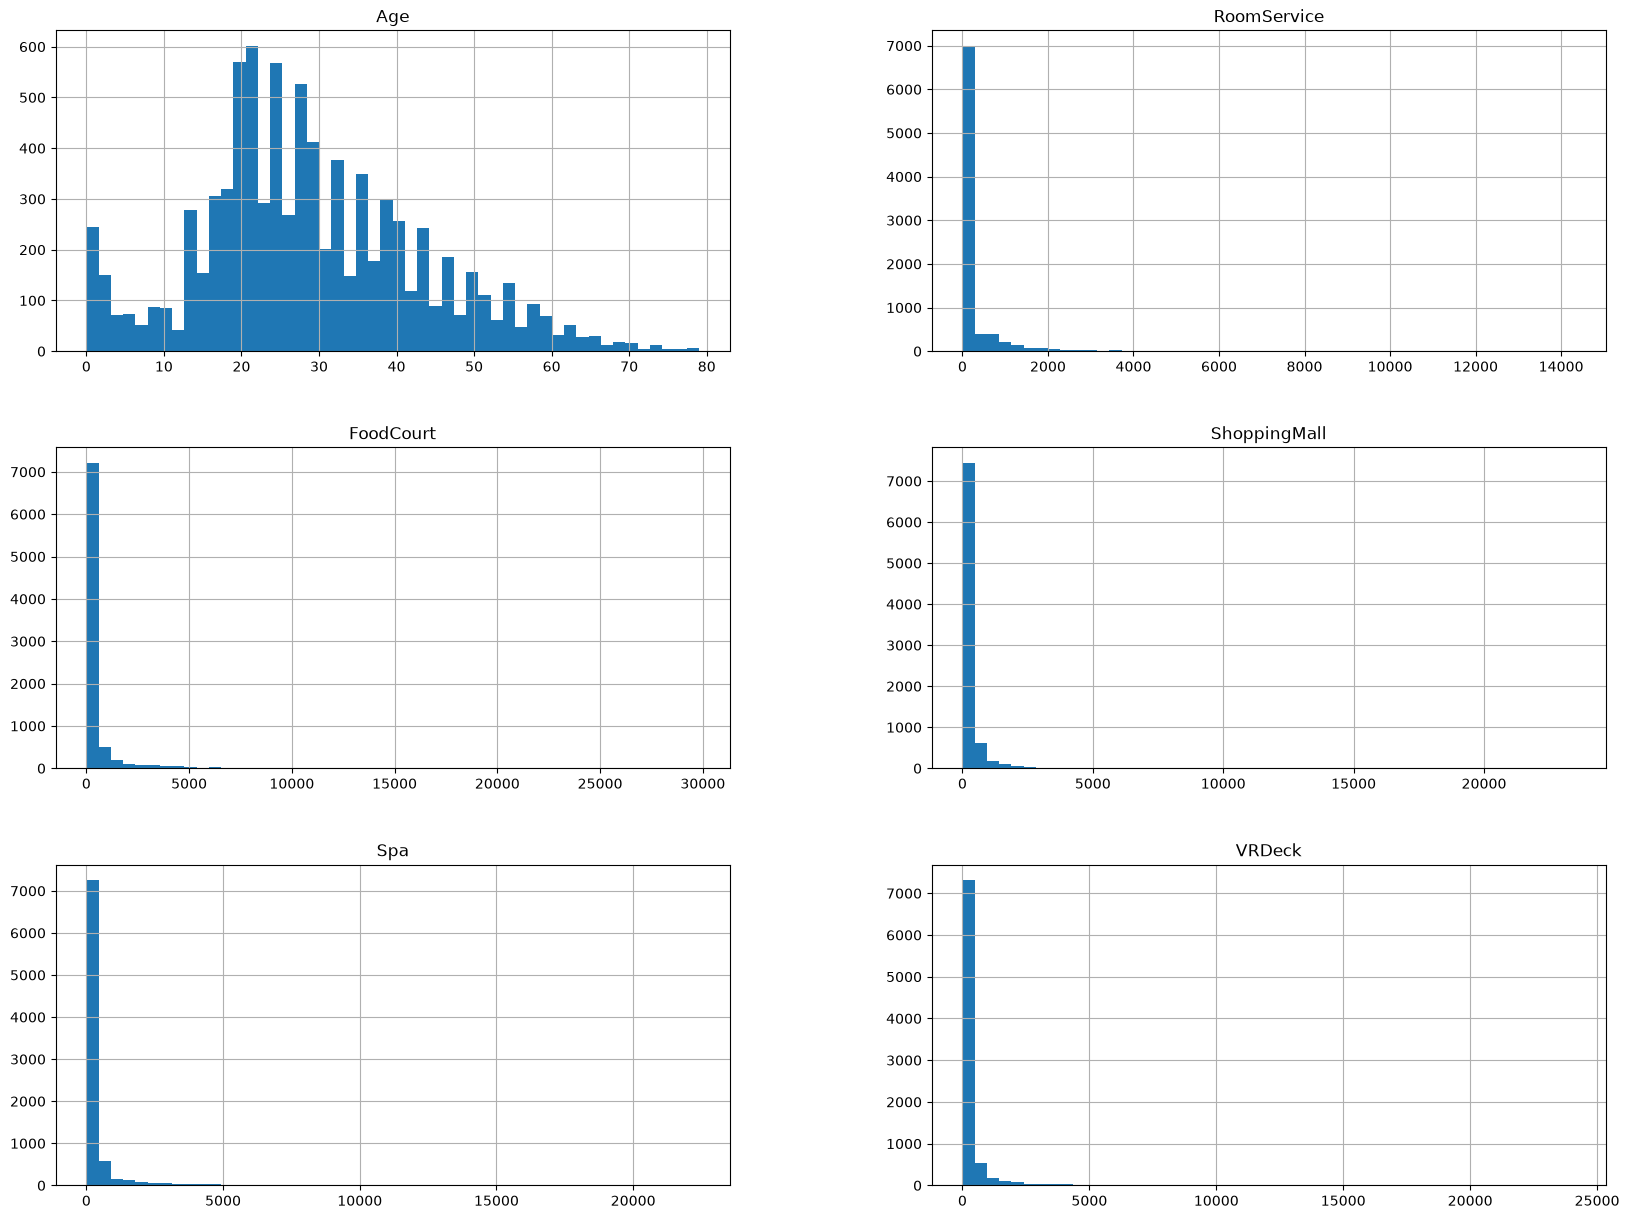

In [47]:
# vizualizing nnumerical columns of the raw_train_df

raw_train_df_num.hist(bins=50, figsize=(20,15))